In [7]:
import sys
sys.path.append("..")

In [8]:
import shap
import joblib
import pandas as pd
from src.pipeline import preprocess_data

# Load data and model
df = pd.read_csv("../data/raw/creditcard.csv")
df = df.drop_duplicates()
X_train, X_test, y_train, y_test = preprocess_data(df)
model = joblib.load("../models/xgboost_fraud_model.pkl")

In [9]:
# Verify everything loaded correctly
print("X_test shape:", X_test.shape)
print("Model type:", type(model))

X_test shape: (56746, 30)
Model type: <class 'xgboost.sklearn.XGBClassifier'>


In [10]:
# Create SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (56746, 30)


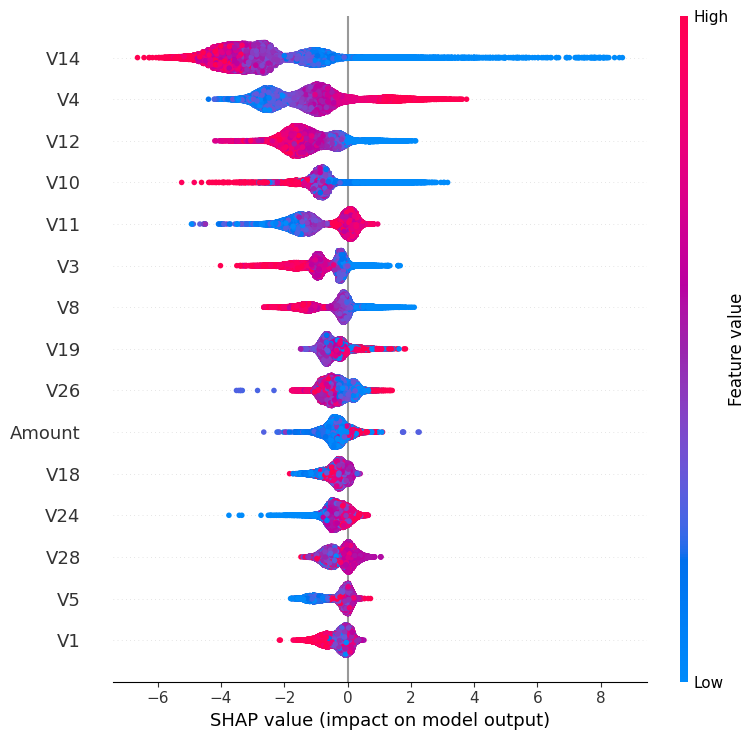

Plot saved.


In [12]:
# Plot top 15 most important features
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.tight_layout()
plt.savefig("../reports/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

# SHAP Feature Importance Analysis

## Key Findings
- **V14 is the most important feature** — widest SHAP spread, reaches -6, strongly drives fraud predictions
- **V4, V12, V10** are next most important features
- **Amount has almost no influence** — dots clustered near zero, model doesn't rely on transaction size
- High V14 values push toward fraud, low V14 values push toward legitimate

## Limitation
V1-V28 are PCA-transformed features — real-world meaning is unknown.
SHAP explains the model technically but results cannot be explained to regulators
or customers in plain business language without original features.

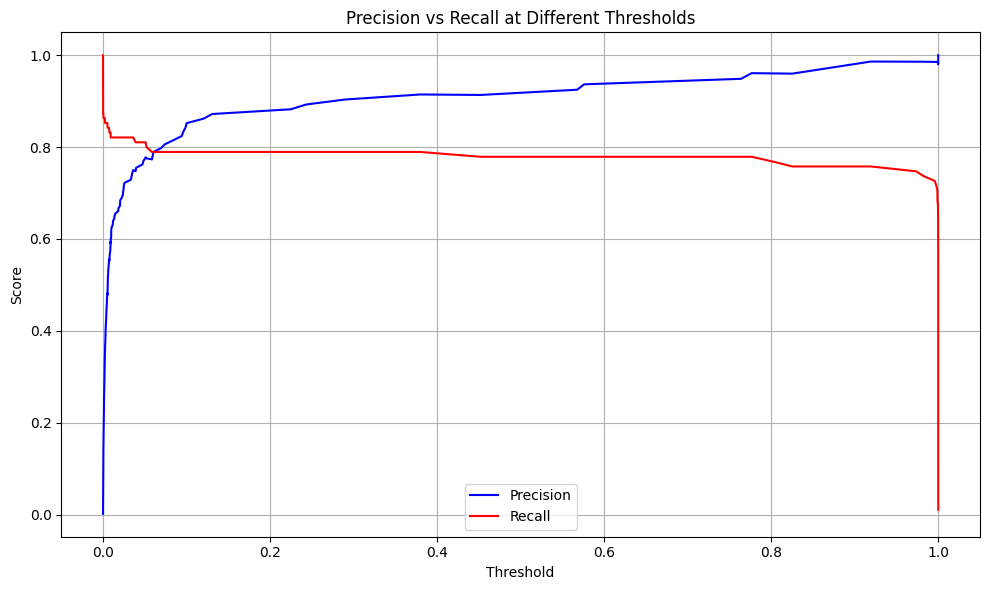

In [13]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# Get fraud probabilities
y_probs = model.predict_proba(X_test)[:, 1]

# Precision-Recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label="Precision", color="blue")
plt.plot(thresholds, recalls[:-1], label="Recall", color="red")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall at Different Thresholds")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("../reports/threshold_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
from sklearn.metrics import f1_score
import numpy as np

# Calculate F1 at every threshold - vectorized
thresholds_to_test = np.arange(0.01, 1.0, 0.01)
f1_scores = []

for thresh in thresholds_to_test:
    preds = (y_probs >= thresh).astype(int)
    f1 = f1_score(y_test, preds, zero_division=0)
    f1_scores.append(f1)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds_to_test[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Best F1 at optimal threshold: {best_f1:.4f}")
print(f"Default F1 at 0.5: {f1_score(y_test, (y_probs >= 0.5).astype(int)):.4f}")

Optimal threshold: 0.7700
Best F1 at optimal threshold: 0.8605
Default F1 at 0.5: 0.8457


In [16]:
from sklearn.metrics import classification_report, confusion_matrix

# Final evaluation at optimal threshold
y_pred_optimal = (y_probs >= best_threshold).astype(int)

print(f"=== Final Model Evaluation at Threshold {best_threshold:.2f} ===\n")
print(classification_report(y_test, y_pred_optimal, target_names=["Legitimate", "Fraud"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_optimal))

=== Final Model Evaluation at Threshold 0.77 ===

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.96      0.78      0.86        95

    accuracy                           1.00     56746
   macro avg       0.98      0.89      0.93     56746
weighted avg       1.00      1.00      1.00     56746

Confusion Matrix:
[[56648     3]
 [   21    74]]


## Threshold Tuning Results

- Default threshold (0.5): F1 = 0.8457, Precision = 0.93, Recall = 0.78
- Optimal threshold (0.77): F1 = 0.8605, Precision = 0.96, Recall = 0.78

### Business Decision
Raising threshold from 0.5 to 0.77 increased precision from 0.93 to 0.96
with no loss in recall. Same fraud caught, fewer false alarms.

### Final Confusion Matrix at 0.77
- Correctly flagged fraud: 74/95
- Missed fraud: 21/95  
- Legitimate wrongly flagged: 3/56,651

### Limitation
Optimal threshold was selected to maximize F1. In production, the bank
would define the threshold based on cost of missed fraud vs cost of
false positives — not purely F1.